In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TeachingRatings.csv to TeachingRatings.csv


In [ ]:
df = pd.read_csv('TeachingRatings.csv')

In [ ]:
df.head()

,rownames,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,1,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,2,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,3,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,4,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,5,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5


In [ ]:
df.columns

Index(['rownames', 'minority', 'age', 'gender', 'credits', 'beauty', 'eval',
       'division', 'native', 'tenure', 'students', 'allstudents', 'prof'],
      dtype='object')

In [ ]:
minority_data = df[df["minority"] == "yes"]
minority_data["tenure"].value_counts()

,count
tenure,
yes,54
no,10


In [ ]:
percentage = (
    (minority_data["tenure"] == "yes").sum()
    / len(minority_data)
) * 100

print("Percentage of minority professors who are tenured: ", percentage)

Percentage of minority professors who are tenured:  84.375


In [ ]:
pd.crosstab(df["minority"], df["tenure"], normalize="index") * 100


tenure,no,yes
minority,,
no,23.057644,76.942356
yes,15.625000,84.375000


For non-minority professors, the percentage is 76.94%. Therefore, the tenure rate is higher among visible minority professors by about 7.44 percentage points, suggesting that tenure status differs by minority status.

In [ ]:
df.groupby("tenure")["age"].agg(["mean", "std"])

,mean,std
tenure,,
no,50.186275,6.946372
yes,47.850416,10.420056


Yes, the average age differs. Untenured professors have a higher mean age (50.19 years) than tenured professors (47.85 years).

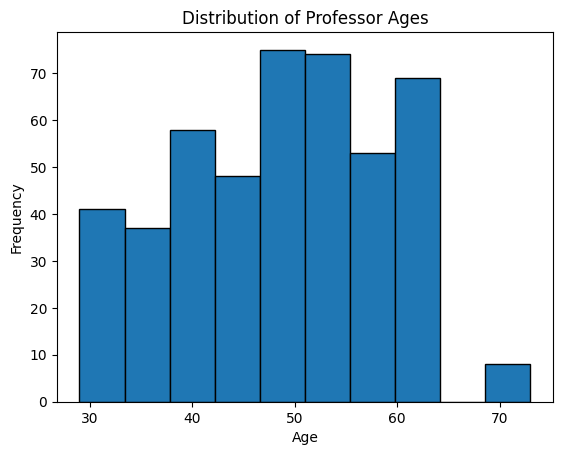

In [ ]:
plt.hist(df["age"], bins=10, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Professor Ages")
plt.show()

A histogram works better for the age variable because age is a continuous numerical variable. A histogram shows how the ages are distributed across different intervals. The graph shows that most professors are between approximately 45 and 65 years old, while there are fewer professors at the lower and higher age ranges.A bar graph is mainly used when you're comparing separate categories

In [ ]:
gender_counts = df["gender"].value_counts()
print(gender_counts)

gender
male      268
female    195
Name: count, dtype: int64


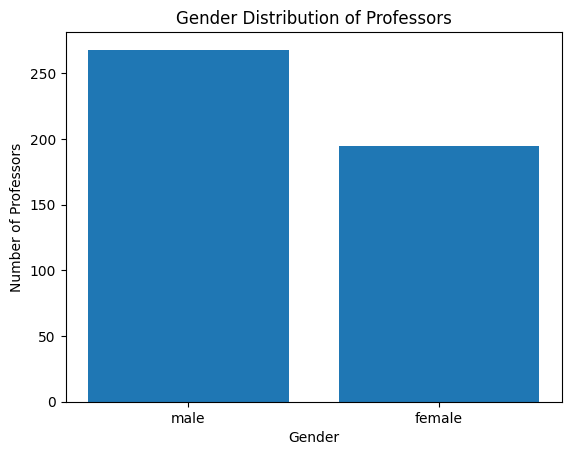

In [ ]:
plt.bar(gender_counts.index, gender_counts.values)
plt.xlabel("Gender")
plt.ylabel("Number of Professors")
plt.title("Gender Distribution of Professors")
plt.show()

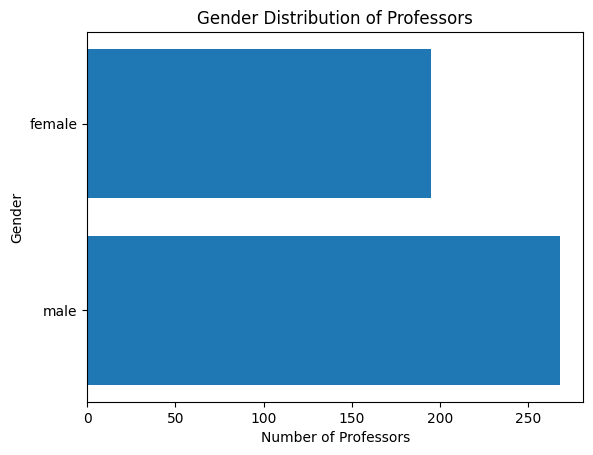

In [ ]:
plt.barh(gender_counts.index, gender_counts.values)
plt.xlabel("Number of Professors")
plt.ylabel("Gender")
plt.title("Gender Distribution of Professors")
plt.show()

pyplot.bar() creates a vertical bar graph where the categories are displayed along the x-axis. pyplot.barh() creates a horizontal bar graph where the categories are displayed along the y-axis. Both can be used to compare categorical data such as gender.

In [ ]:
tenured = df[df["tenure"] == "yes"]
median_eval = tenured["eval"].median()
print("Median evaluation score for tenured professors: ", median_eval)

Median evaluation score for tenured professors:  4.0
